In [1]:
import os

**Dataset Link**
https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# Load the dataset
df = pd.read_csv("/kaggle/input/bike-sharing-dataset/hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [9]:
print(df['season'].unique())
print(df['yr'].unique())
print(df['mnth'].unique())
print(df['hr'].unique())
print(df['holiday'].unique())
print(df['weekday'].unique())
print(df['workingday'].unique())
print(df['weathersit'].unique())
print(df['temp'].unique())
print(df['atemp'].unique())
print(df['hum'].unique())
print(df['windspeed'].unique())
print(df['casual'].unique().max())
print(df['registered'].unique().max())

[1 2 3 4]
[0 1]
[ 1  2  3  4  5  6  7  8  9 10 11 12]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[0 1]
[6 0 1 2 3 4 5]
[0 1]
[1 2 3 4]
[0.24 0.22 0.2  0.32 0.38 0.36 0.42 0.46 0.44 0.4  0.34 0.3  0.26 0.16
 0.14 0.18 0.12 0.28 0.1  0.08 0.06 0.04 0.02 0.52 0.56 0.58 0.6  0.48
 0.54 0.5  0.66 0.64 0.62 0.68 0.7  0.74 0.76 0.72 0.78 0.82 0.8  0.86
 0.88 0.9  0.84 0.92 0.94 0.96 0.98 1.  ]
[0.2879 0.2727 0.2576 0.3485 0.3939 0.3333 0.4242 0.4545 0.4394 0.4091
 0.2273 0.2121 0.197  0.1667 0.1364 0.1061 0.1212 0.1818 0.2424 0.1515
 0.3182 0.0606 0.0758 0.0909 0.303  0.0303 0.0455 0.     0.0152 0.3636
 0.5    0.5303 0.5455 0.5909 0.4697 0.5152 0.6212 0.6061 0.4848 0.3788
 0.6364 0.6515 0.6667 0.5758 0.5606 0.6818 0.697  0.7424 0.7727 0.7576
 0.7273 0.7121 0.803  0.7879 0.8333 0.8182 0.8485 0.8788 0.8636 0.8939
 0.9242 0.9091 0.9545 0.9848 1.    ]
[0.81 0.8  0.75 0.86 0.76 0.77 0.72 0.82 0.88 0.87 0.94 1.   0.71 0.66
 0.57 0.46 0.42 0.39 0.44 0.47 0.5  0.43 0.4 

In [12]:
df['cnt'].unique().min()

1

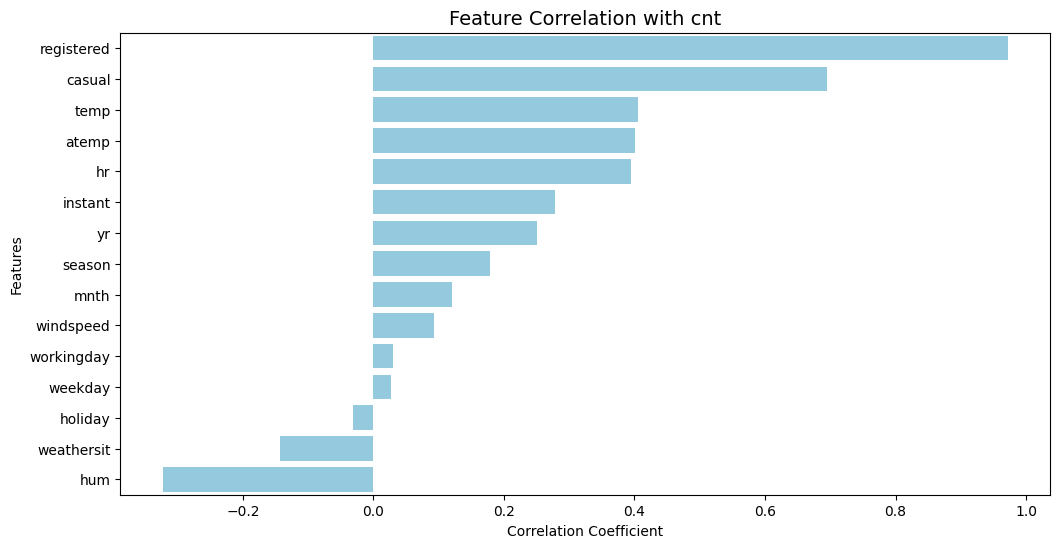

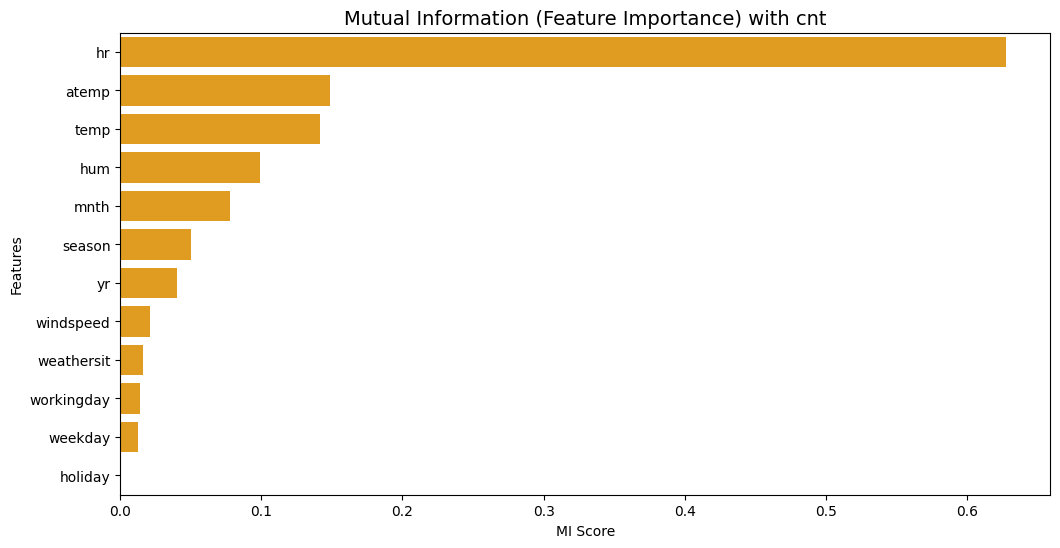

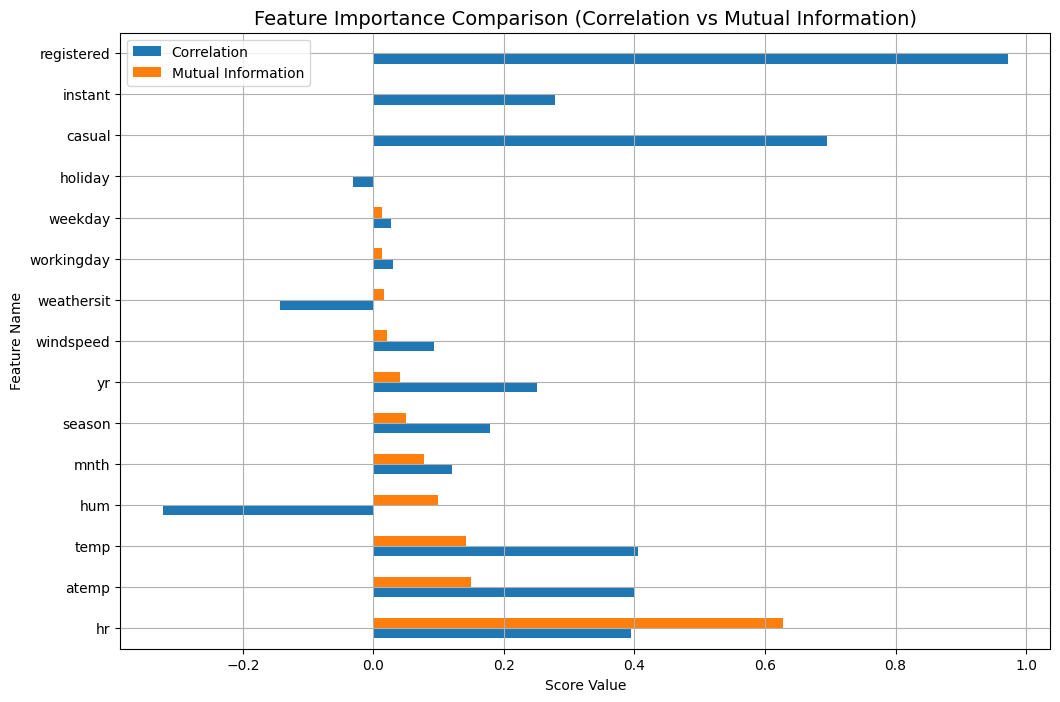

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

# Drop unnecessary columns
X = df.drop(['instant','dteday','casual','registered','cnt'], axis=1)
y = df['cnt']

# Encode categorical features
X_encoded = X.copy()
for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        X_encoded[col] = X_encoded[col].astype('category').cat.codes

# Correlation with target
corr = df.corr(numeric_only=True)
corr_target = corr["cnt"].drop("cnt").sort_values(ascending=False)

# Mutual Information (non-linear)
mi = mutual_info_regression(X_encoded, y)
mi_scores = pd.Series(mi, index=X_encoded.columns).sort_values(ascending=False)

# Combine and visualize
plt.figure(figsize=(12,6))
sns.barplot(x=corr_target.values, y=corr_target.index, color='skyblue', label='Correlation')
plt.title("Feature Correlation with cnt", fontsize=14)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(x=mi_scores.values, y=mi_scores.index, color='orange', label='Mutual Information')
plt.title("Mutual Information (Feature Importance) with cnt", fontsize=14)
plt.xlabel("MI Score")
plt.ylabel("Features")
plt.show()

# Combine both metrics side-by-side 
compare_df = pd.DataFrame({
    'Correlation': corr_target,
    'Mutual Information': mi_scores
}).sort_values(by='Mutual Information', ascending=False)

compare_df.plot(kind='barh', figsize=(12,8))
plt.title("Feature Importance Comparison (Correlation vs Mutual Information)", fontsize=14)
plt.xlabel("Score Value")
plt.ylabel("Feature Name")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Remove unwanted features 
df.drop(columns=['dteday'], inplace=True)

In [11]:
# Copy the contents of dataframe
df_original = df.copy()
df_copy = df.copy()
print("Contents copied successfully!")

Contents copied successfully!


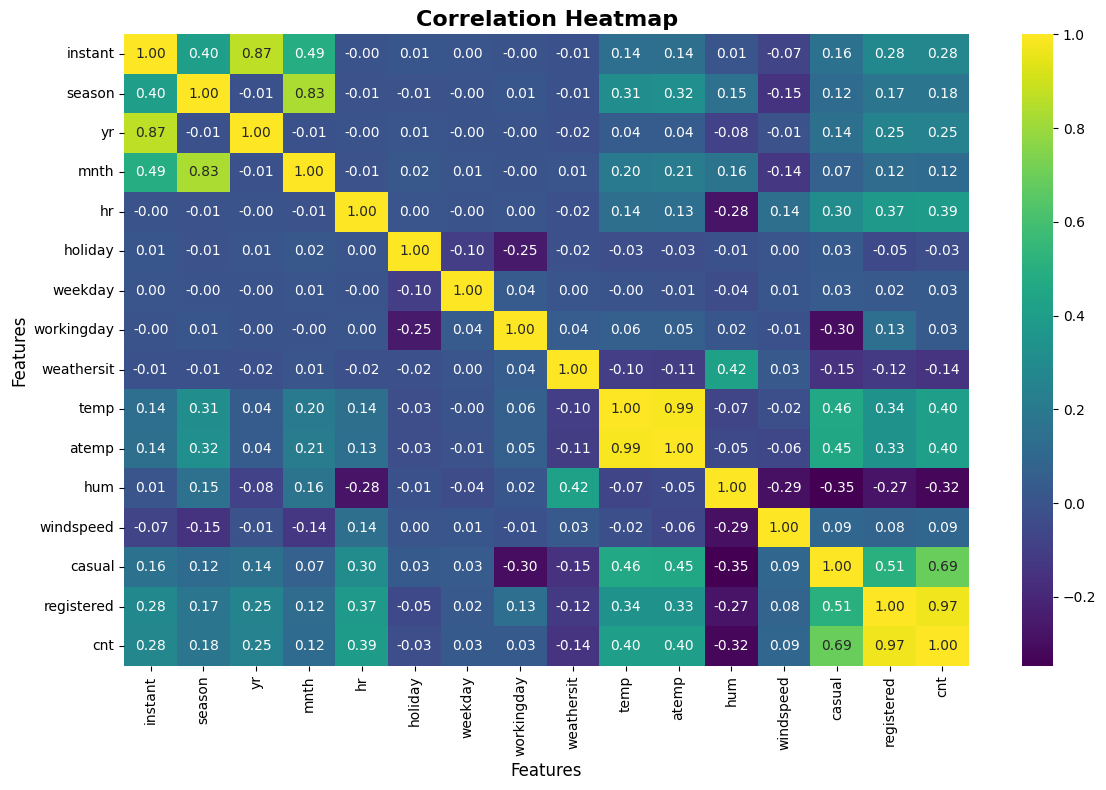

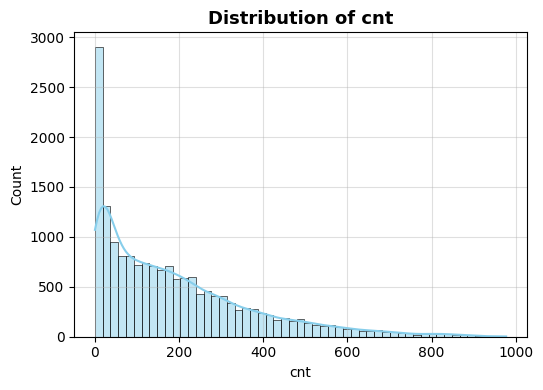

In [33]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_copy.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

# Distribution Graphs
plt.figure(figsize=(15, 4))

# Math Score
plt.subplot(1, 3, 1)
sns.histplot(df_copy['cnt'], kde=True, color='skyblue')
plt.title("Distribution of cnt", fontsize=13, fontweight='bold')
plt.xlabel("cnt")
plt.ylabel("Count")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [12]:
# Extract the independent and depenedent variables
X = df_copy.drop(columns=['cnt'])
y = df_copy['cnt']

# Split into  Train and test the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# Scale the dataset and save the scalers
import pickle

from sklearn.preprocessing import StandardScaler

# Scale X and y separately
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

with open("elasticnet_scalers.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("ElasticNet scalers dumped successfully!")

ElasticNet scalers dumped successfully!


In [38]:
# Principle Component Analysisi(PCA) for feature extraction
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features", X_train.shape[1])
print("Decomposition features(PCA)", X_train_pca.shape[1])

Original features 15
Decomposition features(PCA) 11


In [15]:
# Optuna objective function with Elastic Net
from sklearn.linear_model import ElasticNet

def objective(trial):
    # Suggest Hyperparameters
    l1_ratio = trial.suggest_float('l1_ratio', 1e-5, 0.1, log=True)
    alpha = trial.suggest_float('alpha', 1e-4, 1.0, log=True)
    max_iter = trial.suggest_int('max_iter', 200, 2000, step=200)
    tol = trial.suggest_float('tol', 1e-5, 1e-4, log=True)
    selection = trial.suggest_categorical('selection', ['cyclic', 'random'])
    precompute = trial.suggest_categorical('precompute', [True, False])
    fit_intercept = trial.suggest_categorical('fit_intercept', [True,False])

    # Build a model
    model = ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        max_iter=max_iter,
        tol=tol,
        selection=selection,
        precompute=precompute,
        fit_intercept=fit_intercept
    )
    
    # Cross validation for R2 score with 7 fold 
    score = cross_val_score(
        model,
        X_train_pca,
        y_train,
        cv=7,
        n_jobs=-1,
        verbose=2
    )
    return np.mean(score)

In [39]:
# Optuna optimization
import optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Best hyperparameters and best score
print("Best Hyperparameters: ",study.best_params)
print("Best Score : ", study.best_value)

best_params = study.best_params

# Train with the best model
best_elasticnet = ElasticNet(
    alpha=best_params['alpha'],
    l1_ratio=best_params['l1_ratio'],
    max_iter=best_params['max_iter'],
    tol=best_params['tol'],
    selection=best_params['selection'],
    precompute=best_params['precompute'],
    fit_intercept=best_params['fit_intercept']
)

best_elasticnet.fit(X_train_pca, y_train_scaled)
y_pred = best_elasticnet.predict(X_test_pca)

[I 2025-10-31 09:38:12,456] A new study created in memory with name: no-name-013206aa-a666-480b-9040-fbbde4d8a8e2


  0%|          | 0/30 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    1.9s remaining:    1.4s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    2.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished


[I 2025-10-31 09:38:14,594] Trial 0 finished with value: 0.9849200936224963 and parameters: {'l1_ratio': 0.011971671742092063, 'alpha': 0.08926522371218037, 'max_iter': 1600, 'tol': 1.846655970003667e-05, 'selection': 'random', 'precompute': True, 'fit_intercept': True}. Best is trial 0 with value: 0.9849200936224963.
[I 2025-10-31 09:38:14,750] Trial 1 finished with value: -0.10798306445279694 and parameters: {'l1_ratio': 1.1815677390225094e-05, 'alpha': 0.001187589519950873, 'max_iter': 1000, 'tol': 6.119733082212782e-05, 'selection': 'random', 'precompute': True, 'fit_intercept': False}. Best is trial 0 with value: 0.9849200936224963.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished


...

[I 2025-10-31 09:38:18,322] Trial 24 finished with value: 0.9904540790747118 and parameters: {'l1_ratio': 0.04993130486256327, 'alpha': 0.000999951137099561, 'max_iter': 1400, 'tol': 1.3673572817171853e-05, 'selection': 'cyclic', 'precompute': False, 'fit_intercept': True}. Best is trial 12 with value: 0.9904546727016154.
[I 2025-10-31 09:38:18,483] Trial 25 finished with value: 0.9904546705274075 and parameters: {'l1_ratio': 0.017687933587603916, 'alpha': 0.00010071110278547743, 'max_iter': 1000, 'tol': 1.8081776785710013e-05, 'selection': 'cyclic', 'precompute': False, 'fit_intercept': True}. Best is trial 12 with value: 0.9904546727016154.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished


[I 2025-10-31 09:38:18,648] Trial 26 finished with value: -0.10798587688231406 and parameters: {'l1_ratio': 0.09731944079853734, 'alpha': 0.00034857838482348996, 'max_iter': 1600, 'tol': 2.579208710436376e-05, 'selection': 'cyclic', 'precompute': False, 'fit_intercept': False}. Best is trial 12 with value: 0.9904546727016154.
[I 2025-10-31 09:38:18,812] Trial 27 finished with value: 0.9904514882149843 and parameters: {'l1_ratio': 0.003606633624235891, 'alpha': 0.002015473449021345, 'max_iter': 800, 'tol': 1.3573413713961378e-05, 'selection': 'cyclic', 'precompute': False, 'fit_intercept': True}. Best is trial 12 with value: 0.9904546727016154.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished


[I 2025-10-31 09:38:18,975] Trial 28 finished with value: 0.990454529144941 and parameters: {'l1_ratio': 0.043009468721978396, 'alpha': 0.0005674790863346824, 'max_iter': 1200, 'tol': 3.7650631735056465e-05, 'selection': 'cyclic', 'precompute': False, 'fit_intercept': True}. Best is trial 12 with value: 0.9904546727016154.
[I 2025-10-31 09:38:19,142] Trial 29 finished with value: 0.9904546709235815 and parameters: {'l1_ratio': 0.011276159450533622, 'alpha': 0.00019772354095656138, 'max_iter': 1400, 'tol': 1.9312681695436466e-05, 'selection': 'random', 'precompute': False, 'fit_intercept': True}. Best is trial 12 with value: 0.9904546727016154.
Best Hyperparameters:  {'l1_ratio': 0.06992301715898998, 'alpha': 0.0001451419454965796, 'max_iter': 1400, 'tol': 1.0541858870017581e-05, 'selection': 'cyclic', 'precompute': False, 'fit_intercept': True}
Best Score :  0.9904546727016154


In [40]:
y_pred = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()

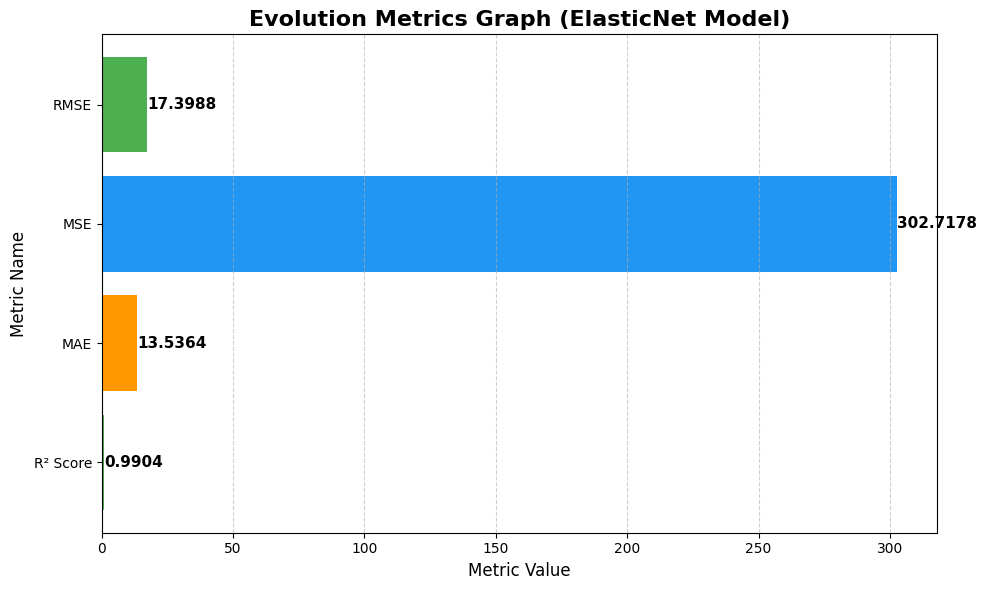

In [17]:
# Define metrics
import matplotlib.pyplot as plt
import seaborn as sns

metrics = {
    'R² Score': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'MSE': mean_squared_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
}

# Create a figure
plt.figure(figsize=(10,6))

# Horizontal bar chart for better readability
plt.barh(list(metrics.keys()), list(metrics.values()), color=['#4CAF50', '#FF9800', '#2196F3'])

# Title and labels
plt.title('Evolution Metrics Graph (ElasticNet Model)', fontsize=16, fontweight='bold')
plt.xlabel('Metric Value', fontsize=12)
plt.ylabel('Metric Name', fontsize=12)

# Add metric values beside bars
for i, (key, value) in enumerate(metrics.items()):
    plt.text(value + 0.01, i, f"{value:.4f}", va='center', fontsize=11, fontweight='bold')

# Grid and style
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

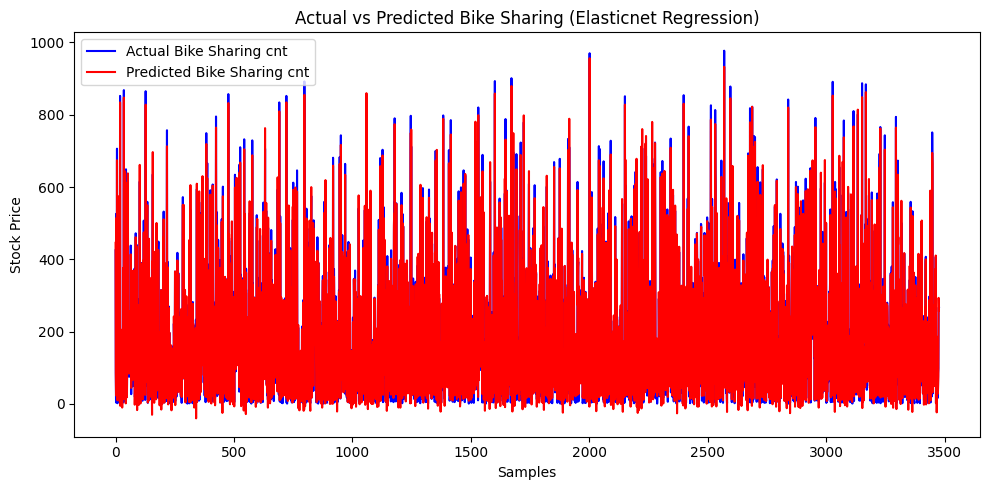

In [44]:
# Plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Bike Sharing cnt', color='blue')
plt.plot(y_pred, label='Predicted Bike Sharing cnt', color='red')
plt.title('Actual vs Predicted Bike Sharing (Elasticnet Regression)')
plt.xlabel('Samples')
plt.ylabel('Stock Price')
plt.legend()
plt.tight_layout()
plt.show()

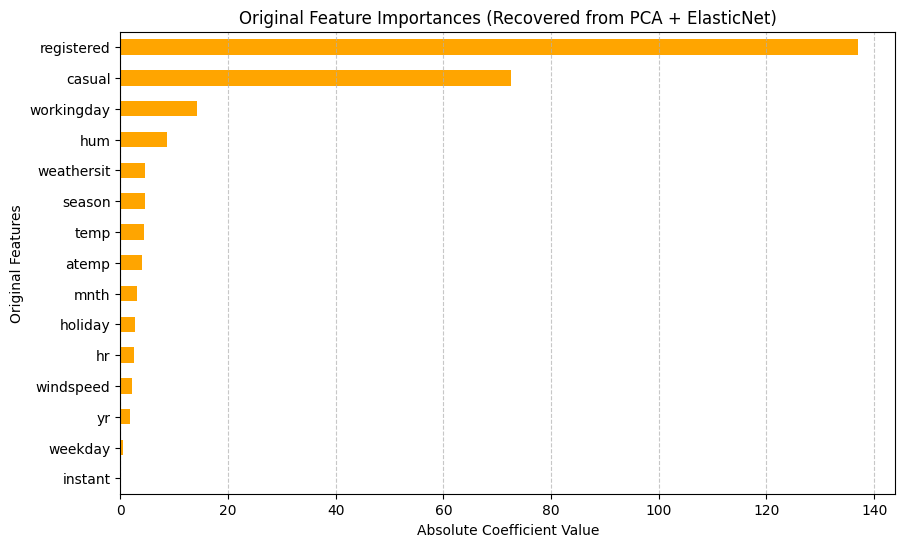

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get ElasticNet coefficients (from PCA space)
elasticnet_coefs = best_elasticnet.coef_

# Get PCA components and map them back to original feature space
# Each PCA component is a linear combination of original features
original_feature_importance = np.dot(pca.components_.T, elasticnet_coefs)

# Use original feature names (from X_train)
feature_names = X_train.columns

# Convert to pandas Series
feature_importance = pd.Series(np.abs(original_feature_importance), index=feature_names)

# Sort by importance
feature_importance = feature_importance.sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='orange')
plt.title("Original Feature Importances (Recovered from PCA + ElasticNet)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Original Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

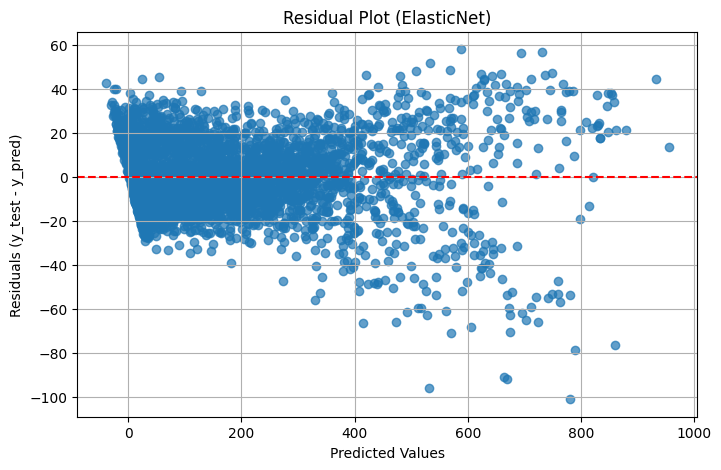

In [52]:
y_pred = best_elasticnet.predict(X_test_pca)

# Calculate residuals
residuals = y_test - y_pred

# Residual plot (Predicted vs Residuals)
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot (ElasticNet)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (y_test - y_pred)")
plt.grid(True)
plt.show()

In [18]:
# Import Optuna visualizations
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_contour,
    plot_param_importances,
    plot_edf,
    plot_slice,
    plot_intermediate_values
)

# Create list of all visualizations with descriptive names
plots = [
    ("Optimization History", plot_optimization_history(study)),
    ("Parallel Coordinate", plot_parallel_coordinate(study)),
    ("Contour Plot", plot_contour(study)),
    ("Parameter Importances", plot_param_importances(study)),
    ("Empirical Distribution Function (EDF)", plot_edf(study)),
    ("Parameter Slice Plot", plot_slice(study)),                # NEW — shows effect of each hyperparameter
    ("Intermediate Values (Learning Curve)", plot_intermediate_values(study))  # NEW — shows trial progress
]

# Display all plots in loop with clear titles
for name, fig in plots:
    print(f"\n{name}")
    fig.show()

[W 2025-10-31 09:08:25,794] You need to set up the pruning feature to utilize `plot_intermediate_values()`



Optimization History



Parallel Coordinate



Contour Plot



Parameter Importances



Empirical Distribution Function (EDF)



Parameter Slice Plot



Intermediate Values (Learning Curve)


In [41]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('x_scaler', x_scaler),
    ('pca', pca),
    ('elasticnet', best_elasticnet)
])

pipe.fit(X_train, y_train_scaled)
joblib.dump({'pipe': pipe, 'y_scaler': y_scaler}, "elasticnet_pipeline.pkl")
print("Model + y-scaler saved successfully!")

Model + y-scaler saved successfully!
